# Phase 1 — Cohort & Retention Analysis

Repeat Purchase & Churn Intelligence — see [`00_problem_framing.md`](../00_problem_framing.md) for the
business question this serves, and [`PROGRESS_LOG.md`](../PROGRESS_LOG.md) for the full debugging history
behind the decisions below (kept out of this notebook to keep it readable).

**What this notebook does:** builds each user's order timeline, defines the churn threshold from observed
data rather than an arbitrary cutoff, and produces the four charts used in the project summary.

**Data constraint that shapes everything below:** Instacart's competition dataset deliberately includes
only users with **4–100 historical orders** — there are no first-time or one-and-done users in this data.
So this analysis measures *drift among already-established repeat customers*, not first-to-second-purchase
churn. See `00_problem_framing.md` for why that's a meaningful distinction, not a footnote.

## Setup

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL
from dotenv import load_dotenv

load_dotenv("../.env")

engine = create_engine(URL.create(
    "mysql+mysqlconnector",
    username=os.environ["MYSQL_USER"],
    password=os.environ["MYSQL_PASSWORD"],
    host=os.environ["MYSQL_HOST"],
    port=int(os.environ["MYSQL_PORT"]),
    database=os.environ["MYSQL_DATABASE"],
))

CHART_DIR = os.path.join("..", "charts")
os.makedirs(CHART_DIR, exist_ok=True)

# Palette (validated default, dataviz skill)
BLUE, ORANGE, MUTED, GRID = "#2a78d6", "#eb6834", "#898781", "#e1e0d9"
INK, SECONDARY_INK = "#0b0b0b", "#52514e"
STATUS_GOOD, STATUS_WARNING, STATUS_CRITICAL = "#0ca30c", "#fab219", "#d03b3b"

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "Arial"],
    "axes.edgecolor": GRID,
    "axes.labelcolor": SECONDARY_INK,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
})

def style_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.grid(axis="x")
    ax.tick_params(length=0)

## 1. Building the order timeline — relative time, not calendar cohorts

Instacart's `orders` table has no absolute order date, only `order_number` (sequence) and
`days_since_prior_order` (relative gap). The spec's literal ask — weekly/monthly signup cohorts —
isn't achievable as written, so each user's timeline is built in **relative time**: cumulative days
since *their own* first order, via a running window sum. This isolates lifecycle stage from
seasonal/calendar effects, arguably a cleaner basis for comparison across users than calendar cohorts.

The DDL below is the canonical version in [`sql/01_cohort_retention.sql`](../sql/01_cohort_retention.sql)
(materialized as tables since they're reused by every query in this notebook and expensive to
recompute — window functions over 3.4M rows).

In [2]:
# order_timeline / user_tenure / user_rfm are expensive to rebuild (~10 min on this
# machine's disk-bound MySQL for the largest one) so CREATE TABLE IF NOT EXISTS makes
# reruns of this notebook idempotent instead of dropping and rebuilding every time.
with engine.begin() as conn:
    conn.execute(text("""
        CREATE TABLE IF NOT EXISTS order_timeline AS
        SELECT
            o.order_id,
            o.user_id,
            o.eval_set,
            o.order_number,
            o.order_dow,
            o.order_hour_of_day,
            o.days_since_prior_order,
            SUM(COALESCE(o.days_since_prior_order, 0)) OVER (
                PARTITION BY o.user_id ORDER BY o.order_number
                ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
            ) AS days_since_first_order,
            MAX(o.order_number) OVER (PARTITION BY o.user_id) AS lifetime_orders
        FROM orders o
    """))
    table_exists = conn.execute(text("SHOW TABLES LIKE 'order_timeline'")).fetchone() is not None
    if table_exists and conn.execute(text("SELECT COUNT(*) FROM order_timeline")).scalar() == 0:
        table_exists = False
    if not table_exists:
        conn.execute(text("ALTER TABLE order_timeline ADD PRIMARY KEY (order_id)"))
        conn.execute(text("ALTER TABLE order_timeline ADD INDEX (user_id)"))

    conn.execute(text("""
        CREATE TABLE IF NOT EXISTS user_tenure AS
        SELECT
            user_id,
            MAX(days_since_first_order) AS tenure_days,
            MAX(lifetime_orders) AS lifetime_orders
        FROM order_timeline
        GROUP BY user_id
    """))
    has_pk = conn.execute(text("""
        SELECT COUNT(*) FROM information_schema.STATISTICS
        WHERE table_schema = DATABASE() AND table_name = 'user_tenure' AND index_name = 'PRIMARY'
    """)).scalar()
    if not has_pk:
        conn.execute(text("ALTER TABLE user_tenure ADD PRIMARY KEY (user_id)"))

print("order_timeline and user_tenure ready (created if missing, reused if already built).")

order_timeline and user_tenure ready (created if missing, reused if already built).


## 2. Retention / survival curve

`tenure_days = MAX(days_since_first_order)` per user. Retention at checkpoint T = fraction of the
cohort with `tenure_days >= T`. This is a survival-curve framing appropriate for sparse transactional
data with no continuous activity tracking.

**Sanity check that mattered:** the first pass at these numbers looked implausibly high for a churn
study (day-90 retention ~75%). Checking `MIN(lifetime_orders)` across all users came back as **4** —
confirming the dataset structurally excludes anyone who hasn't already made 4+ purchases. These curves
describe *retention among established users*, not acquisition-to-repeat conversion. See
`00_problem_framing.md` for the full implication.

In [3]:
retention = pd.read_sql("""
    SELECT
        (SELECT COUNT(*) FROM user_tenure) AS cohort_size,
        SUM(tenure_days >= 7)  / (SELECT COUNT(*) FROM user_tenure) AS d7,
        SUM(tenure_days >= 14) / (SELECT COUNT(*) FROM user_tenure) AS d14,
        SUM(tenure_days >= 30) / (SELECT COUNT(*) FROM user_tenure) AS d30,
        SUM(tenure_days >= 60) / (SELECT COUNT(*) FROM user_tenure) AS d60,
        SUM(tenure_days >= 90) / (SELECT COUNT(*) FROM user_tenure) AS d90
    FROM user_tenure
""", engine)

min_orders = pd.read_sql("SELECT MIN(lifetime_orders) AS min_orders FROM user_tenure", engine)
print(f"MIN(lifetime_orders) across all users = {min_orders.loc[0, 'min_orders']}  (confirms survivorship filter)")
retention

MIN(lifetime_orders) across all users = 4  (confirms survivorship filter)


,cohort_size,d7,d14,d30,d60,d90
0,206209,0.9994,0.9969,0.9765,0.8901,0.7467


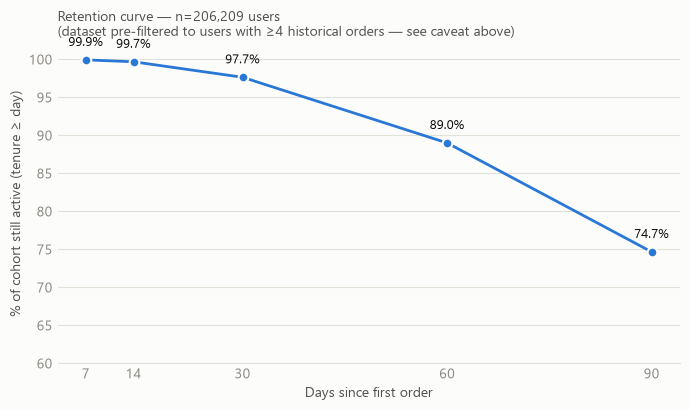

In [4]:
days = [7, 14, 30, 60, 90]
values = [retention.loc[0, f"d{d}"] * 100 for d in days]

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(days, values, color=BLUE, linewidth=2, marker="o", markersize=7,
        markerfacecolor=BLUE, markeredgecolor="#fcfcfb", markeredgewidth=1.5, zorder=3)
for d, v in zip(days, values):
    ax.annotate(f"{v:.1f}%", (d, v), textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=9, color=INK)
ax.set_ylim(60, 102)
ax.set_xticks(days)
ax.set_xlabel("Days since first order")
ax.set_ylabel("% of cohort still active (tenure ≥ day)")
ax.set_title(
    f"Retention curve — n={retention.loc[0,'cohort_size']:,} users\n"
    "(dataset pre-filtered to users with ≥4 historical orders — see caveat above)",
    fontsize=10, loc="left", color=SECONDARY_INK,
)
style_axes(ax)
fig.tight_layout()
fig.savefig(os.path.join(CHART_DIR, "01_retention_curve.png"), dpi=150)
plt.show()

## 3. Order-gap distribution → the churn threshold

`days_since_prior_order` is the gap between consecutive orders. Its distribution defines what a
"normal" reorder cadence looks like, which in turn defines the churn threshold — the goal is to
derive that number from the data rather than assert a round one.

**Important data quirk:** Instacart **censors this field at 30** — any true gap of 30+ days is
recorded as exactly 30. That shows up below as a sharp spike at `gap_days = 30`.

In [5]:
gaps = pd.read_sql("""
    SELECT days_since_prior_order AS gap_days, COUNT(*) AS n
    FROM order_timeline WHERE days_since_prior_order IS NOT NULL
    GROUP BY gap_days ORDER BY gap_days
""", engine)

gap_series = pd.read_sql("""
    SELECT days_since_prior_order
    FROM order_timeline WHERE days_since_prior_order IS NOT NULL
""", engine)["days_since_prior_order"]

pct_at_cap = (gap_series == 30).mean() * 100
pct_le_15 = (gap_series <= 15).mean() * 100
p90 = gap_series.quantile(0.90)

print(f"n gaps observed        = {len(gap_series):,}")
print(f"75th percentile        = {gap_series.quantile(0.75):.0f} days")
print(f"90th percentile        = {p90:.0f} days")
print(f"% of gaps <= 15 days   = {pct_le_15:.1f}%")
print(f"% of gaps == 30 (cap)  = {pct_at_cap:.1f}%")

n gaps observed        = 3,214,874
75th percentile        = 15 days
90th percentile        = 30 days
% of gaps <= 15 days   = 75.3%
% of gaps == 30 (cap)  = 11.5%


**Churn threshold: 30 days**, for two independent reasons that converge on the same number:

1. **Behavioral** — the 90th percentile of observed gaps lands almost exactly at 30 days; the long
   tail of "still normal" reordering has effectively ended by then.
2. **Structural** — Instacart's own censoring means the data literally cannot distinguish a 30-day
   gap from a 300-day gap. Setting the threshold any higher would assert precision the data doesn't
   have.

This is written up with the numbers in `00_problem_framing.md`.

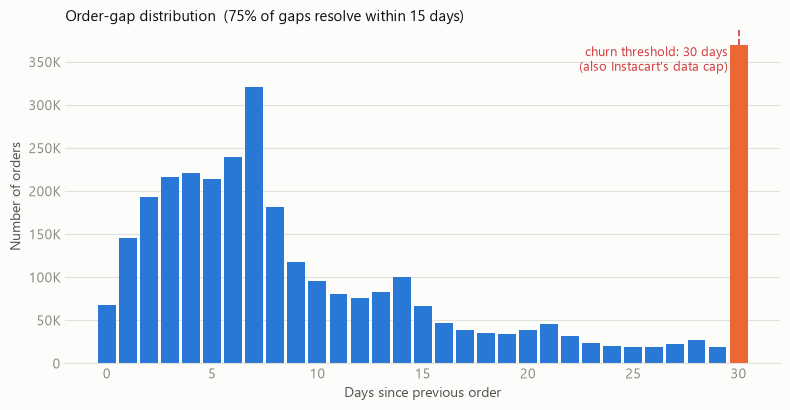

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.2))
colors = [ORANGE if g == 30 else BLUE for g in gaps["gap_days"]]
ax.bar(gaps["gap_days"], gaps["n"], color=colors, width=0.85)
ax.axvline(x=30, color=STATUS_CRITICAL, linestyle="--", linewidth=1.2, zorder=0)
ax.text(29.5, gaps["n"].max() * 0.92, "churn threshold: 30 days\n(also Instacart's data cap)",
        ha="right", fontsize=9, color=STATUS_CRITICAL)
ax.set_xlabel("Days since previous order")
ax.set_ylabel("Number of orders")
ax.set_title(f"Order-gap distribution  ({pct_le_15:.0f}% of gaps resolve within 15 days)",
             fontsize=11, loc="left")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}K" if x >= 1000 else int(x)))
style_axes(ax)
ax.grid(axis="x", visible=False)
ax.grid(axis="y", color=GRID)
fig.tight_layout()
fig.savefig(os.path.join(CHART_DIR, "02_gap_distribution.png"), dpi=150)
plt.show()

## 4. RFM segmentation & risk tiers

No price data exists in Instacart, so "Monetary" is proxied by **average basket size** (items per
order) rather than spend — documented explicitly rather than silently relabeling basket size as
"monetary."

**Recency needed a fix.** There's no shared "today" in this dataset (no calendar clock) — only
per-user relative time. A first attempt computed recency as `global_max_tenure - user_tenure`, which
is just an inverted relabeling of tenure itself and produced a nonsensical "79% likely lost" result.
The fix: `last_gap_days`, the gap observed immediately before each user's *final* known order — a
self-relative signal that needs no shared clock, and answers a defensible question: by the time we
stopped observing this user, had their cadence already started widening? This is also the same
gap-widening signal the project spec identifies as the strongest churn indicator, and it's the
definition Phase 2/3's label will build on.

**Risk tiers** (finalized in `00_problem_framing.md`): Active (≤15d) · Gently slowing (15–30d) ·
At/past churn threshold (≥30d).

In [7]:
with engine.begin() as conn:
    conn.execute(text("""
        CREATE TABLE IF NOT EXISTS user_rfm AS
        SELECT
            t.user_id,
            lg.last_gap_days,
            t.lifetime_orders AS frequency,
            b.avg_basket_size AS monetary_proxy
        FROM user_tenure t
        JOIN (
            SELECT ot.user_id, ot.days_since_prior_order AS last_gap_days
            FROM order_timeline ot
            JOIN user_tenure ut ON ut.user_id = ot.user_id AND ot.order_number = ut.lifetime_orders
        ) lg ON lg.user_id = t.user_id
        JOIN (
            SELECT ot.user_id, AVG(basket.n_items) AS avg_basket_size
            FROM order_timeline ot
            JOIN (
                SELECT order_id, COUNT(*) AS n_items
                FROM order_products
                GROUP BY order_id
            ) basket ON basket.order_id = ot.order_id
            WHERE ot.eval_set IN ('prior', 'train')
            GROUP BY ot.user_id
        ) b ON b.user_id = t.user_id
    """))
    has_pk = conn.execute(text("""
        SELECT COUNT(*) FROM information_schema.STATISTICS
        WHERE table_schema = DATABASE() AND table_name = 'user_rfm' AND index_name = 'PRIMARY'
    """)).scalar()
    if not has_pk:
        conn.execute(text("ALTER TABLE user_rfm ADD PRIMARY KEY (user_id)"))

print("user_rfm ready (created if missing, reused if already built).")

user_rfm ready (created if missing, reused if already built).


In [8]:
tiers = pd.read_sql("""
    SELECT
        CASE
            WHEN last_gap_days <= 15 THEN '1. Active (normal cadence)'
            WHEN last_gap_days < 30 THEN '2. Gently slowing'
            ELSE '3. At/past churn threshold'
        END AS tier,
        COUNT(*) AS n_users
    FROM user_rfm
    GROUP BY tier ORDER BY tier
""", engine)
tiers

,tier,n_users
0,1. Active (normal cadence),104720
1,2. Gently slowing,38303
2,3. At/past churn threshold,63186


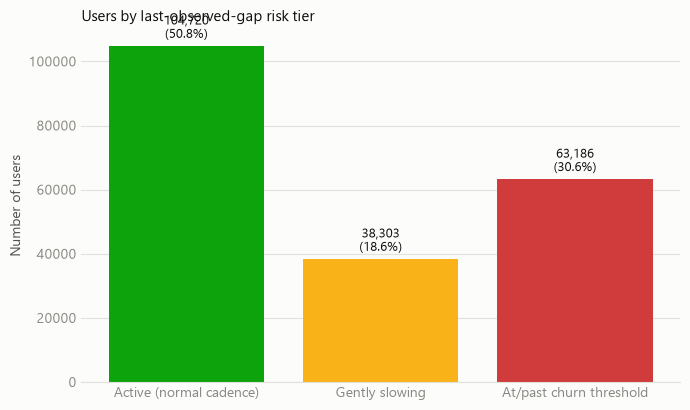

In [9]:
tier_colors = {
    "1. Active (normal cadence)": STATUS_GOOD,
    "2. Gently slowing": STATUS_WARNING,
    "3. At/past churn threshold": STATUS_CRITICAL,
}
fig, ax = plt.subplots(figsize=(7, 4.2))
x_pos = range(len(tiers))
bars = ax.bar(x_pos, tiers["n_users"], color=[tier_colors[t] for t in tiers["tier"]])
for b, n in zip(bars, tiers["n_users"]):
    ax.annotate(f"{n:,}\n({n/tiers['n_users'].sum()*100:.1f}%)",
                (b.get_x() + b.get_width()/2, b.get_height()),
                textcoords="offset points", xytext=(0, 6), ha="center", fontsize=9)
ax.set_ylabel("Number of users")
ax.set_title("Users by last-observed-gap risk tier", fontsize=11, loc="left")
ax.set_xticks(list(x_pos))
ax.set_xticklabels([t[3:] for t in tiers["tier"]])
style_axes(ax)
ax.grid(axis="x", visible=False)
fig.tight_layout()
fig.savefig(os.path.join(CHART_DIR, "03_risk_tiers.png"), dpi=150)
plt.show()

## 5. Category-level retention

Do "staple" categories (produce, dairy) retain users better than discretionary/one-off categories?
Restricted to `eval_set IN ('prior', 'train')` since only those orders have basket contents
(the 75,000 held-out `test` orders don't).

**Runtime note:** the query below takes roughly 6 minutes to run. It joins the full 33.8M-row `order_products` table through to `departments` and finishes with `COUNT(DISTINCT user_id)`, which forces MySQL to deduplicate across the entire exploded join in a temp table — a CPU-bound cost, not a caching one (see `PROGRESS_LOG.md`, 2026-09-20, for the full diagnosis of this and a related buffer-pool sizing issue). A two-step materialized rewrite was tried and did not improve on this, so the runtime is accepted as-is.

In [10]:
cat = pd.read_sql("""
    SELECT department, n_users, avg_tenure_days
    FROM (
        SELECT
            d.department,
            COUNT(DISTINCT ot.user_id) AS n_users,
            AVG(t.tenure_days) AS avg_tenure_days
        FROM order_products op
        JOIN order_timeline ot ON ot.order_id = op.order_id AND ot.eval_set IN ('prior','train')
        JOIN products p ON p.product_id = op.product_id
        JOIN departments d ON d.department_id = p.department_id
        JOIN user_tenure t ON t.user_id = ot.user_id
        GROUP BY d.department
    ) x
    ORDER BY avg_tenure_days DESC
""", engine)
cat

,department,n_users,avg_tenure_days
0,babies,34782,268.631493
1,bulk,12973,264.328342
2,dairy eggs,191861,257.873089
3,snacks,177070,256.169306
4,produce,194331,255.416922
5,bakery,143772,254.438706
6,deli,137143,253.736963
7,breakfast,117338,253.136100
8,beverages,175482,251.903447
9,meat seafood,116851,249.651015


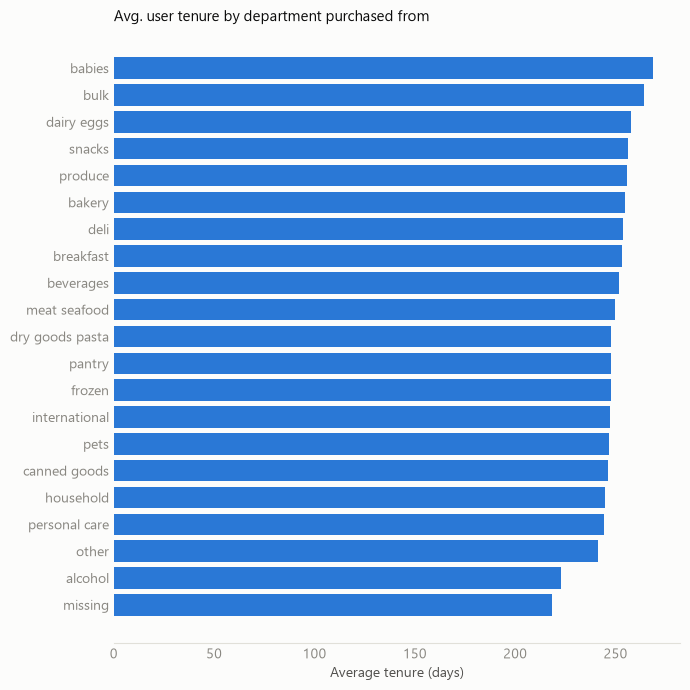

In [11]:
fig, ax = plt.subplots(figsize=(7, 7))
y_pos = range(len(cat))
ax.barh(y_pos, cat["avg_tenure_days"], color=BLUE)
ax.set_yticks(y_pos)
ax.set_yticklabels(cat["department"])
ax.invert_yaxis()
ax.set_xlabel("Average tenure (days)")
ax.set_title("Avg. user tenure by department purchased from", fontsize=11, loc="left")
style_axes(ax)
ax.grid(axis="y", visible=False)
fig.tight_layout()
fig.savefig(os.path.join(CHART_DIR, "04_category_retention.png"), dpi=150)
plt.show()

**Reading:** babies and bulk categories show the longest average tenure; alcohol and the
unclassified/"missing" department the shortest. Directionally supports the staple-vs-discretionary
retention hypothesis from `00_problem_framing.md`, though the spread (~218–269 days) is moderate,
not dramatic — a real signal, not the whole story.

## Summary — what Phase 1 established

| Decision | Answer | Basis |
|---|---|---|
| Cohort definition | Relative time since each user's own first order | No calendar date field exists |
| Churn threshold | **30 days** since last order | 90th pct of gap distribution ≈ Instacart's own 30-day censoring cap |
| Recency signal | `last_gap_days` (self-relative) | Global-max-tenure approach was a mislabeled tenure inversion — see above |
| Monetary proxy | Avg. basket size (items/order) | No price/revenue field in this dataset |
| Scope caveat | Measures drift among established (4+ order) users, not first-to-second-purchase churn | Dataset's own sampling design (`MIN(lifetime_orders) = 4`) |

**Next (Phase 2):** feature engineering off `order_timeline` / `user_rfm` with a strict time cutoff
to avoid leakage, then baselines before models.